In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

#### Functions

In [2]:
def target_by_data_set(df, str_target):
    df_tmp = df.groupby(by='data_set', as_index=False).agg({
        str_target: 'mean',
    })
    df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
    df_tmp.sort_values(by='sort', ascending=True, inplace=True)
    df_tmp.drop('sort', axis=1, inplace=True)

    # plot
    x = df_tmp['data_set']
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by Data Set')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [3]:
def target_by_feature(df, str_col, str_target):
    df_tmp = df[df['data_set'] == 'train'].groupby(by=str_col, as_index=False).agg({
        str_target: 'mean',
    })

    # plot
    x = df_tmp[str_col].astype(str)
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_col}')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [4]:
def target_by_feature_quantile(df, str_col, int_n_quantiles, str_target):
    # get quantile
    df_tmp = df[df['data_set'] == 'train'].copy()
    # replace infs with nan
    df_tmp[str_col] = df_tmp[str_col].replace(np.inf, np.nan)
    # drop missing rows
    df_tmp = df_tmp.dropna(subset=[str_col])
    # get quantile
    df_tmp['quantile'] = pd.qcut(df_tmp[str_col], q=int_n_quantiles, duplicates='drop')
    # min-max
    df_tmp['min'] = df_tmp[str_col]
    df_tmp['max'] = df_tmp[str_col]
    # get target mean by quangtile
    df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'max': 'max',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'{str_target} by {str_col} Quantile')
    ax.set_xlabel(f'{str_col} Quantile')
    ax.set_ylabel(str_target)
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target])
    plt.show()

In [5]:
def get_mean_actual_by_prediction_quantile(X, list_predictions, list_actual, str_target, int_n_quantiles, str_model_type):
    # assign
    X['yhat'] = list_predictions
    X[str_target] = list_actual
    # get quantile
    X['quantile'] = pd.qcut(X['yhat'], q=int_n_quantiles, duplicates='drop')
    # get min
    X['min'] = X['yhat']
    X['predicted'] = X['yhat']
    # group
    df_tmp = X.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'predicted': 'mean',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_model_type} Prediction Quantile')
    ax.set_xlabel('Prediction Quantile')
    ax.set_ylabel(f'Mean {str_target}')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp['predicted'], label='Predicted')
    # legend
    ax.legend()
    
    # save
    str_filename = 'performance.png'
    str_local_path = f'./output/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')
    
    # show
    plt.show()

In [6]:
def map_ltv_range_to_lgd_bin(flt_ltv, dict_bins_ltv):
    for flt_threshold, flt_val in dict_bins_ltv.items():
        if flt_ltv <= flt_threshold:
            return flt_val
    # else
    return np.max(list(dict_bins_ltv.values()))

#### Constants

In [7]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target_tmp = str_task[3:].replace('_in_','_').replace('_dl','')
str_target = f'Early_Pay_Delinquency_{str_target_tmp}_Flag'
print(f'Target: {str_target}')

str_dirname_output = './output'

# for ordering
dict_sort = {
    'train': 1,
    'valid': 2,
    'test': 3,
    'inform': 4,
    'holdout': 5,
}

list_str_inst = [
    # from ben: 2025-02-21
    'CURRENT',
    'SELF',
    # key words
    'CHIME-STRIDE',
    'CHIMEFINAL',
    # from dustin: 2025-02-24
    'SELF FIN',
    'SELF/LEAD',
    'SELFINC/LEAD',
    'SBNASELFLNDR',
    'SBNA SELF',
    'CHIME',
    'CLEO',
    'CLEO AI',
    'VARO',
    'ATLAS',
    'ATLCAPBKSELF',
    'POSSIBLE',
    'POSSIBLE FIN',
    'KIKOFF',
    'SUPER.COM',
    'STEP',
    'STEP MOBILE',
    'BRIGHT',
    'BRIGHT BLDR',
    'FIG TECH INC',
    'SELF/RENT',
    'SELFBILLSE',
    'PROGRESSRES',
    'FLEX',
    'FLEXFINANCE',
]

flt_factor_chime = 1.203
flt_factor_nonchime = 0.936

Project: 20241112-simple-model-test
Task: 13_60_in_720_dl
Subtask: 13_ecnl_evaluation
Target: Early_Pay_Delinquency_60_720_Flag


#### Output directory

In [8]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get data dictionary for mapping descriptions

In [9]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Import data

In [10]:
# import
list_str_filename = [
    'train',
    'test',
    'holdout',
]
list_df = []
for str_filename in tqdm(list_str_filename):
    str_filename_tmp = f'df_{str_filename}.gzip'
    str_uri = f's3://{str_project}/{str_task}/01_data_split/{str_filename_tmp}'
    df = pd.read_parquet(
        str_uri,
    )
    # append
    list_df.append(df)
# concatenate
df = pd.concat(list_df)
# rm too new
df = df[df['request_datetime'] < '2022-12-01'].copy()
# save memory
del list_df
# show
df

100%|██████████| 3/3 [00:03<00:00,  1.09s/it]


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,row,prop_row,data_set,train,test,holdout
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0,0,0.616667,2021-07-01,1,0.000024,train,1,0,0
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,0,NaN,2021-07-01,2,0.000048,train,1,0,0
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,0,NaN,2021-07-01,3,0.000072,train,1,0,0
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,0,1,0.000000,2021-07-01,4,0.000096,train,1,0,0
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,0,1,0.000000,2021-07-01,5,0.000120,train,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,6453589,2022-11-30 23:45:32+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,1,0.000000,2022-11-01,41694,0.999904,holdout,0,0,1
41694,6418453,2022-11-30 23:48:36+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Independent,Michigan,False,...,0,0,0.000000,2022-11-01,41695,0.999928,holdout,0,0,1
41695,6411914,2022-11-30 23:53:12+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Washington,Independent,Washington,True,...,0,0,NaN,2022-11-01,41696,0.999952,holdout,0,0,1
41696,6434554,2022-11-30 23:57:04+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,0,0.137374,2022-11-01,41697,0.999976,holdout,0,0,1


#### Chime tag

In [11]:
df['list_institutions'] = df['str_institution__tu_pmthx'].apply(
    lambda x: eval(x.replace('nan','None')),
)
df['list_institutions'] = df['list_institutions'].apply(
    lambda x: [] if x is None else x,
)
# show
#df

In [12]:
list_str_col_new = []
for str_inst in tqdm(list_str_inst):
    str_col_new = f'{str_inst}_tag'
    df[str_col_new] = df['list_institutions'].apply(
        lambda x: 1 if str_inst in x else 0,
    )
    list_str_col_new.append(str_col_new)

100%|██████████| 29/29 [00:00<00:00, 48.29it/s]


In [13]:
df['sum'] = df[list_str_col_new].sum(axis=1)
df['has_inst_tag'] = df['sum'].apply(
    lambda x: 1 if x > 0 else 0,
)
flt_mn = df['has_inst_tag'].mean()
print(f'Proportion has tag: {flt_mn:0.4f}')
# show
#df

Proportion has tag: 0.1583


#### Get LGD target

Minimum: 0.00


<Axes: ylabel='Density'>

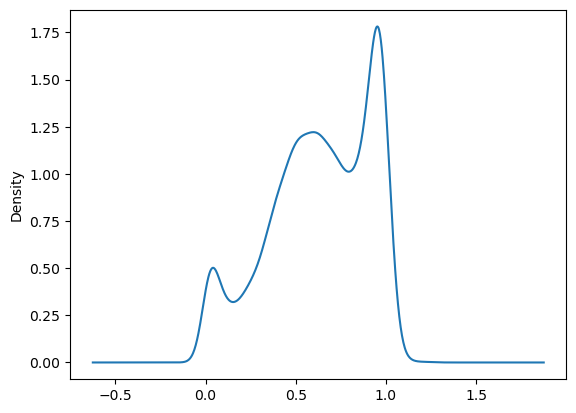

In [14]:
df['loss_at_720'] = df['loss_at_720'].clip(lower=0)
# get proportion of amount financed
df['actual_ecnl'] = df['loss_at_720'] / df['amtfinanced__app']
# create nulls
df['actual_lgd'] = df.apply(
    lambda x: np.nan if x[str_target] == 0 else x['actual_ecnl'],
    axis=1,
)
flt_min = df['actual_lgd'].min()
print(f'Minimum: {flt_min:0.2f}')
df['actual_lgd'].plot(kind='kde')

#### Target mean by data set

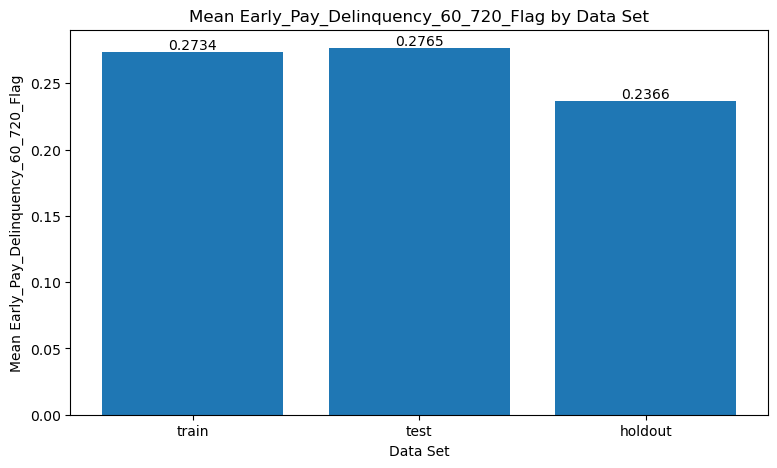

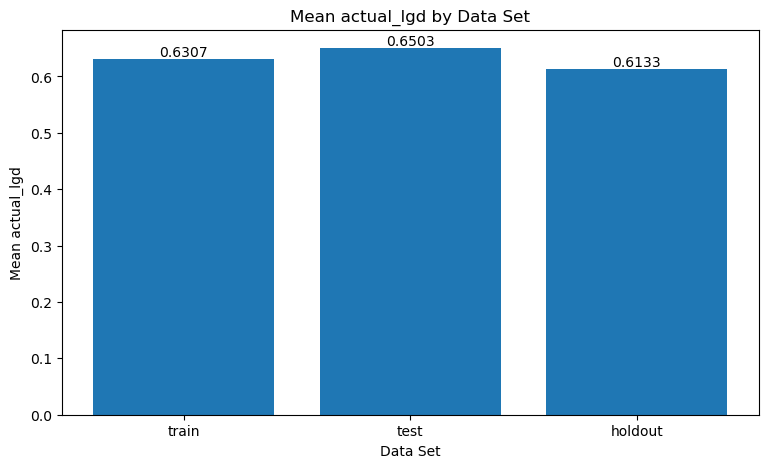

In [15]:
list_cols = [
    str_target,
    'actual_lgd',
]

for col in list_cols:
    target_by_data_set(
        df=df,
        str_target=col,
    )

#### Target mean by BK

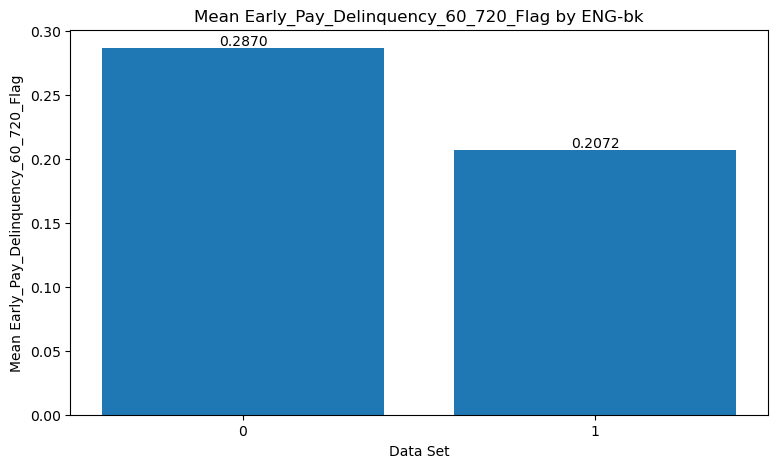

In [16]:
str_col = 'ENG-bk'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by BK (LGD)

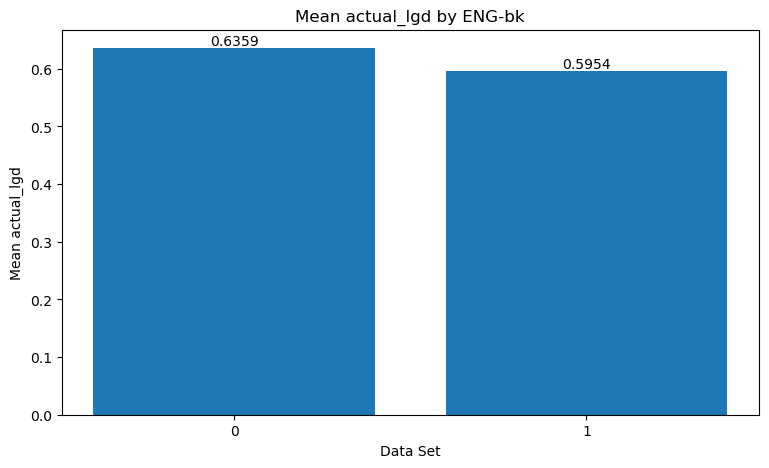

In [17]:
str_col = 'ENG-bk'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target='actual_lgd',
)

#### Target mean by dealer type (PD)

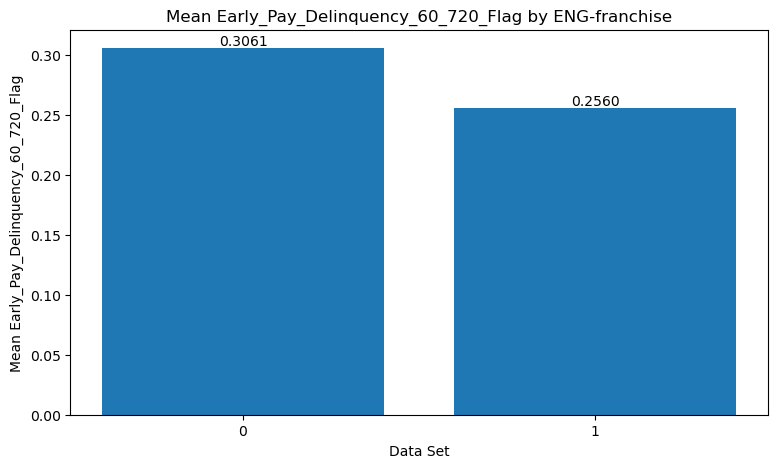

In [18]:
str_col = 'ENG-franchise'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by dealer type (LGD)

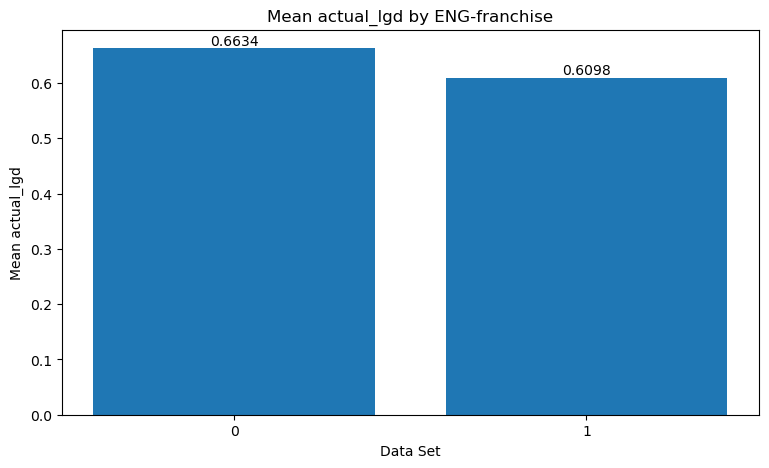

In [19]:
str_col = 'ENG-franchise'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target='actual_lgd',
)

#### Target mean by has a codebtor (PD)

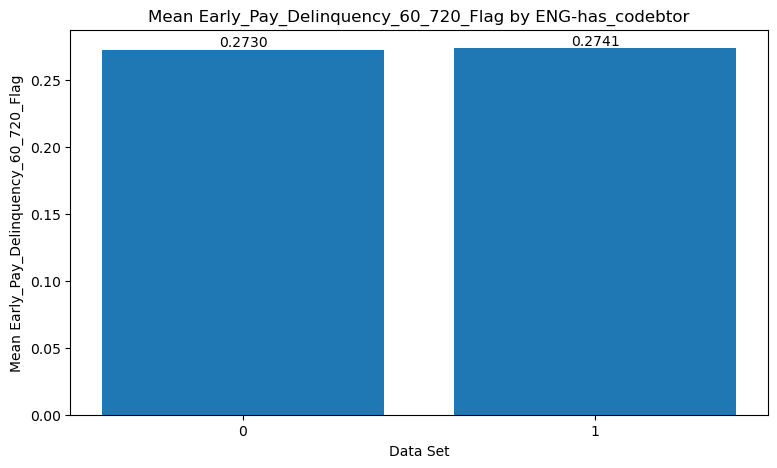

In [20]:
str_col = 'ENG-has_codebtor'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by has a codebtor (LGD)

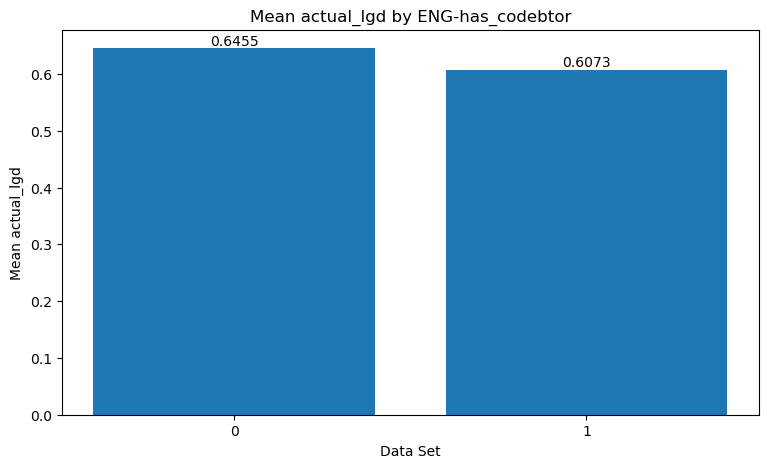

In [21]:
str_col = 'ENG-has_codebtor'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target='actual_lgd',
)

#### Target by LTV Quantile (PD)

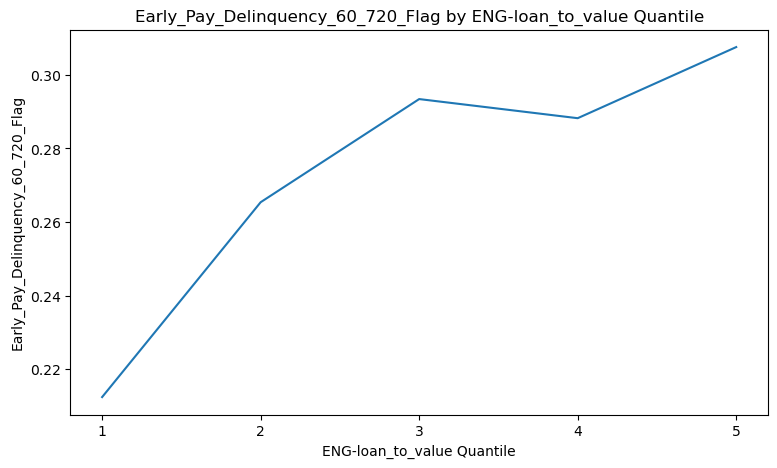

In [22]:
# get quantile
str_col = 'ENG-loan_to_value'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by LTV Quantile (LGD)

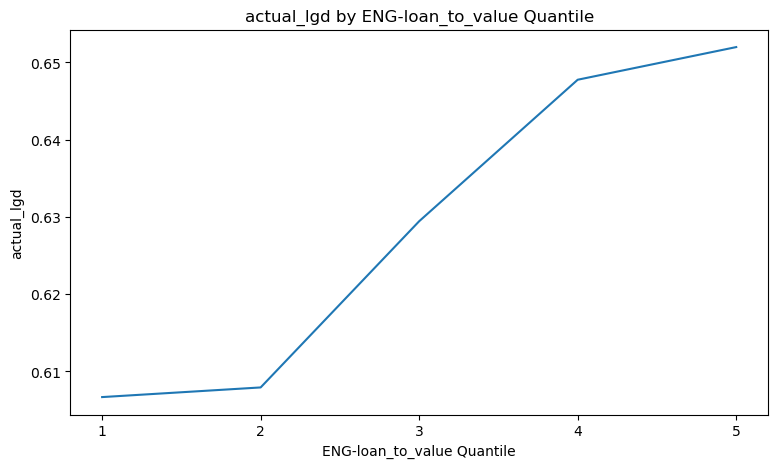

In [23]:
# get quantile
str_col = 'ENG-loan_to_value'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target='actual_lgd',
)

#### Target by income quantile (PD)

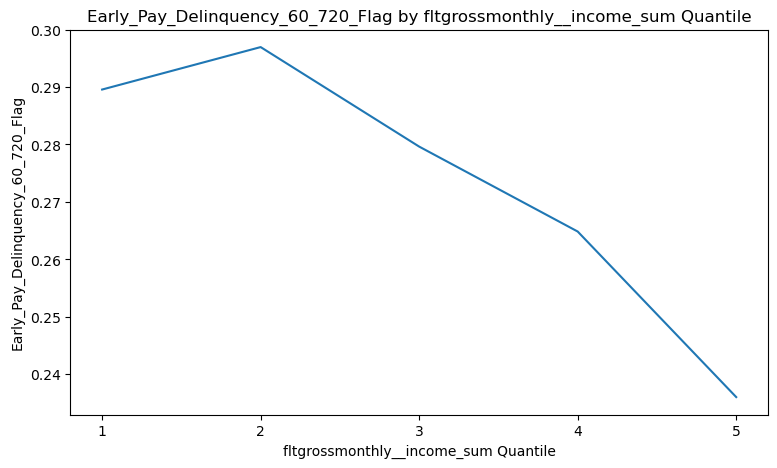

In [24]:
# get quantile
str_col = 'fltgrossmonthly__income_sum'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by income quantile (LGD)

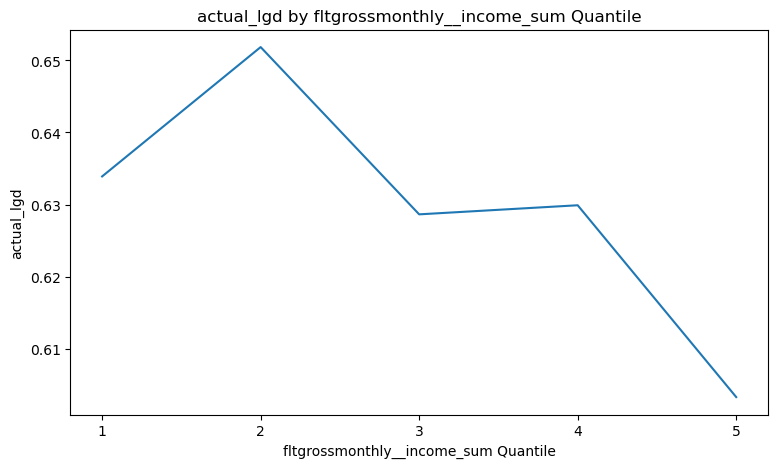

In [25]:
# get quantile
str_col = 'fltgrossmonthly__income_sum'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target='actual_lgd',
)

#### Target by PTI Quantile (PD)

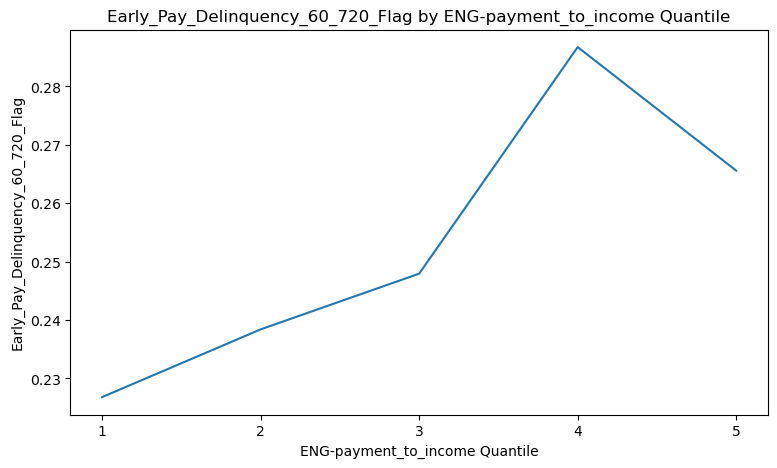

In [26]:
# get quantile
str_col = 'ENG-payment_to_income'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by PTI Quantile (LGD)

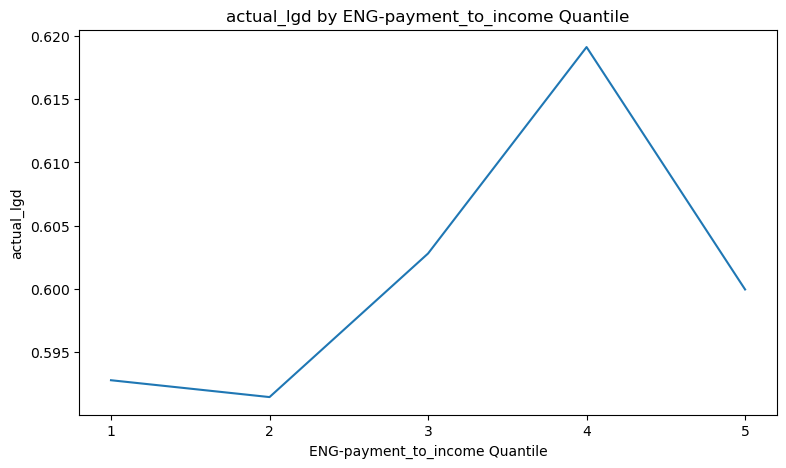

In [27]:
# get quantile
str_col = 'ENG-payment_to_income'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target='actual_lgd',
)

#### Target by DTI quantile (PD)

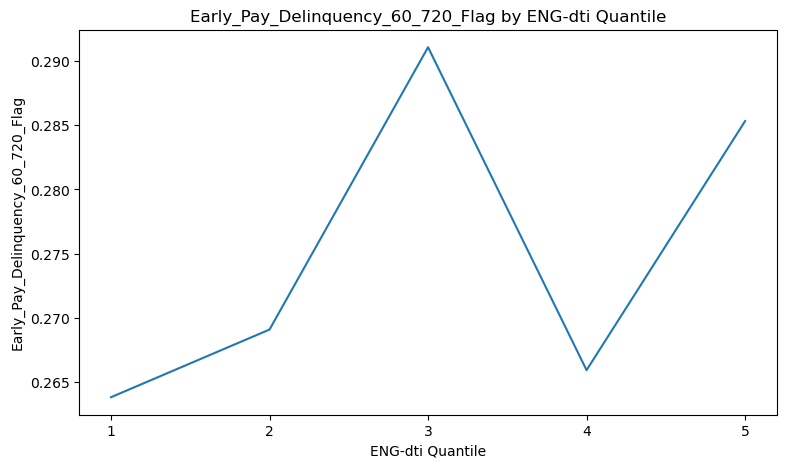

In [28]:
# get quantile
str_col = 'ENG-dti'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by DTI quantile (LGD)

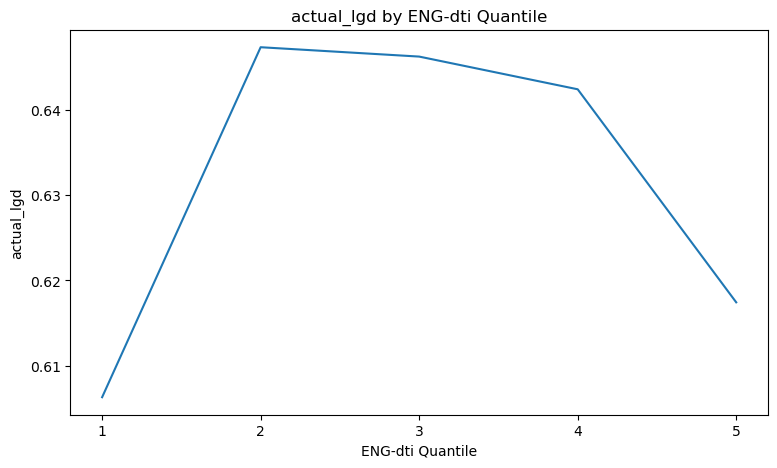

In [29]:
# get quantile
str_col = 'ENG-dti'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target='actual_lgd',
)

#### Payment history (PD)

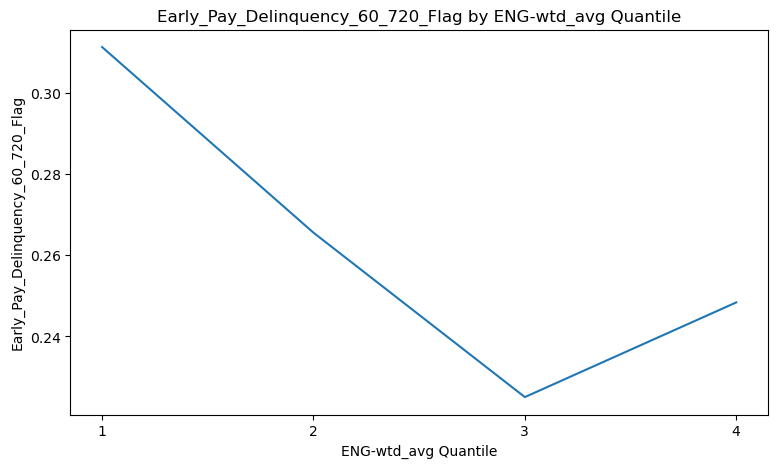

In [30]:
# get quantile
str_col = 'ENG-wtd_avg'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Payment history (LGD)

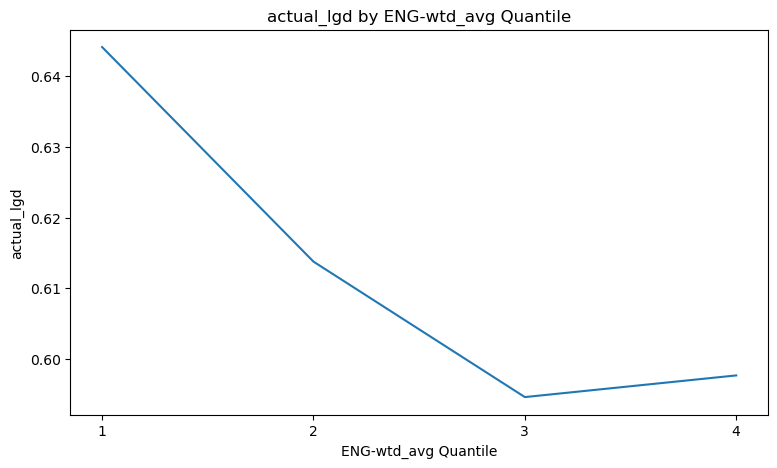

In [31]:
# get quantile
str_col = 'ENG-wtd_avg'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target='actual_lgd',
)

#### Get imputation dictionary

In [32]:
# import
str_filename = 'dict_impute.pkl'
str_local_path = f'../../14_60_in_720_dl_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

# impute
for key, val in tqdm(dict_impute.items()):
    try:
        # replace any infs with nan
        df[key] = df[key].replace(np.inf, np.nan)
        # fillna
        df[key] = df[key].fillna(val)
    except KeyError:
        pass
# show
#df

100%|██████████| 988/988 [00:00<00:00, 1040.25it/s]


#### Get bins

In [33]:
# import
str_filename = 'dict_bins.pkl'
str_local_path = f'../../14_60_in_720_dl_test/02_model/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))

# transform
for key, val in tqdm(dict_bins.items()):
    try:
        df[f'{key}_binned'] = val.transform(df[key])
    except KeyError:
        pass

100%|██████████| 982/982 [00:02<00:00, 475.01it/s]


#### Get PD model

In [34]:
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'../02_model/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
list_cols_model = list(cls_model_inference.feature_names_in_)
df['PD'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]

#### Get LGD

In [35]:
# open
str_filename = 'dict_bins_ltv.pkl'
str_local_path = f'../../create_grid/04_60_in_720_chargeoff_dl/output/{str_filename}'
dict_bins_ltv = pickle.load(open(str_local_path, 'rb'))

# get lgd
df['LGD_mapped'] = df['ENG-loan_to_value'].apply(
    lambda x: map_ltv_range_to_lgd_bin(
        flt_ltv=x,
        dict_bins_ltv=dict_bins_ltv,
    ),
)

# create nans
df['LGD_predicted'] = df.apply(
    lambda x: np.nan if x[str_target] == 0 else x['LGD_mapped'],
    axis=1,
)

In [36]:
dict_bins_ltv

{0.8: 0.5981905993444799,
 1.11: 0.6052616798997871,
 1.21: 0.6154742159583763,
 1.31: 0.6356838066052604,
 1.41: 0.6453188404962024,
 1.51: 0.6536030123642623,
 1.61: 0.6637057085458945,
 2.43: 0.7067715717469841,
 2.526389: 0.8703323201613054}

#### Get ECNL

In [37]:
df = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'first',
    'ENG-bk': 'first',
    'ENG-franchise': 'first',
    'fltgrossmonthly__income_sum': 'sum',
    'ENG-loan_to_value': 'first',
    'PD': 'mean',
    'LGD_mapped': 'mean',
    'LGD_predicted': 'mean',
    str_target: 'first',
    'actual_lgd': 'first',
    'actual_ecnl': 'first',
    'has_inst_tag': 'max',
})
df['ECNL'] = df['PD'] * df['LGD_mapped']
# show
df

,accountid,request_datetime,ENG-bk,ENG-franchise,fltgrossmonthly__income_sum,ENG-loan_to_value,PD,LGD_mapped,LGD_predicted,Early_Pay_Delinquency_60_720_Flag,actual_lgd,actual_ecnl,has_inst_tag,ECNL
0,5514485,2022-10-15 02:35:52.2455863,0,0,3976.280029,1.299997,0.272308,0.635684,NaN,0,NaN,0.000000,0,0.173102
1,5514970,2022-10-15 02:36:32.6396499,0,1,5720.000000,1.295059,0.185809,0.635684,NaN,0,NaN,0.000000,0,0.118116
2,5515245,2022-10-15 02:36:53.5525392,0,1,4822.600098,1.156227,0.165527,0.615474,NaN,0,NaN,0.000000,0,0.101878
3,5515340,2022-10-15 02:37:13.5377961,0,1,4160.000000,1.599743,0.361511,0.663706,NaN,0,NaN,0.000000,0,0.239937
4,5515580,2022-10-15 02:37:34.1144830,0,1,4281.330078,1.363642,0.312610,0.645319,NaN,0,NaN,0.000000,0,0.201733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33687,6461883,2022-11-30 04:54:24+00:00,0,0,5170.340000,1.292084,0.300050,0.635684,0.635684,1,0.792314,0.792314,1,0.190737
33688,6462809,2022-11-30 04:30:22+00:00,0,0,4953.880000,1.281294,0.362060,0.635684,0.635684,1,0.726858,0.726858,0,0.230156
33689,6464120,2022-11-30 00:10:57+00:00,0,1,4246.670000,1.247042,0.206257,0.635684,NaN,0,NaN,0.000000,0,0.131114
33690,6464316,2022-11-30 03:21:17+00:00,1,0,4298.900000,1.462667,0.228601,0.653603,0.653603,1,0.924991,0.924991,1,0.149414


#### Chime penalty

In [38]:
df['ECNL'] = df.apply(
    lambda x: (x['ECNL'] * flt_factor_chime) if x['has_inst_tag'] == 1 else (x['ECNL'] * flt_factor_nonchime),
    axis=1,
)

#### Get app month

In [39]:
df['request_date'] = df['request_datetime'].apply(
    lambda x: x[:10],
)
df['request_date_dtm'] = pd.to_datetime(df['request_date'])
df.sort_values(by='request_date_dtm', ascending=True, inplace=True)
# get month
df['request_month'] = df['request_date_dtm'].apply(
    lambda x: str(x)[:7],
)
df

,accountid,request_datetime,ENG-bk,ENG-franchise,fltgrossmonthly__income_sum,ENG-loan_to_value,PD,LGD_mapped,LGD_predicted,Early_Pay_Delinquency_60_720_Flag,actual_lgd,actual_ecnl,has_inst_tag,ECNL,request_date,request_date_dtm,request_month
1739,5713063,2021-07-26 16:48:39.3211104,1,1,3758.840000,1.587073,0.285371,0.663706,NaN,0,NaN,0.000000,0,0.177281,2021-07-26,2021-07-26,2021-07
1596,5702434,2021-07-26 16:29:29.3903686,1,1,2426.670000,1.311220,0.388352,0.645319,NaN,0,NaN,0.000000,0,0.234572,2021-07-26,2021-07-26,2021-07
1772,5714239,2021-07-26 16:39:34.1121025,0,1,5809.680000,1.432368,0.281267,0.653603,0.653603,1,0.315976,0.315976,0,0.172071,2021-07-26,2021-07-26,2021-07
1611,5704330,2021-07-27 17:18:03.4670093,0,1,5292.430029,1.344091,0.301429,0.645319,NaN,0,NaN,0.000000,0,0.182069,2021-07-27,2021-07-27,2021-07
1866,5717159,2021-07-27 15:57:44.1101223,1,1,7761.310000,1.217125,0.147066,0.635684,NaN,0,NaN,0.000000,0,0.087504,2021-07-27,2021-07-27,2021-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33239,6432871,2022-11-30 02:50:42+00:00,0,1,7777.650000,1.207331,0.085816,0.615474,NaN,0,NaN,0.000000,0,0.049437,2022-11-30,2022-11-30,2022-11
33265,6434234,2022-11-30 02:44:28+00:00,1,1,3760.710000,1.448625,0.242340,0.653603,NaN,0,NaN,0.000000,0,0.148257,2022-11-30,2022-11-30,2022-11
33271,6434554,2022-11-30 23:57:04+00:00,1,1,3206.670000,1.024680,0.156742,0.605262,NaN,0,NaN,0.000000,0,0.088798,2022-11-30,2022-11-30,2022-11
33069,6424839,2022-11-30 00:57:26+00:00,0,0,6228.520000,1.101145,0.242037,0.605262,NaN,0,NaN,0.000000,0,0.137120,2022-11-30,2022-11-30,2022-11


#### Group by month

In [40]:
df = df.groupby(by='request_month', as_index=False).agg({
    'ENG-bk': 'mean',
    'ENG-franchise': 'mean',
    'fltgrossmonthly__income_sum': 'mean',
    'ENG-loan_to_value': 'mean',
    'PD': 'mean',
    'LGD_mapped': 'mean',
    'LGD_predicted': 'mean',
    'ECNL': 'mean',
    str_target: 'mean',
    'actual_lgd': 'mean',
    'actual_ecnl': 'mean',
})
df

,request_month,ENG-bk,ENG-franchise,fltgrossmonthly__income_sum,ENG-loan_to_value,PD,LGD_mapped,LGD_predicted,ECNL,Early_Pay_Delinquency_60_720_Flag,actual_lgd,actual_ecnl
0,2021-07,0.335260,0.734104,5194.571560,1.269539,0.222945,0.632763,0.638501,0.139018,0.132948,0.511152,0.067957
1,2021-08,0.357764,0.742857,5045.609118,1.285675,0.238665,0.635328,0.636207,0.147602,0.176398,0.604332,0.106603
2,2021-09,0.293240,0.728709,4924.688929,1.283663,0.256351,0.634968,0.636393,0.159240,0.188762,0.563223,0.106315
3,2021-10,0.195338,0.687179,4963.709893,1.273044,0.264614,0.633688,0.636336,0.164172,0.239161,0.578279,0.138302
4,2021-11,0.178610,0.682410,4982.907323,1.252019,0.265267,0.631374,0.631894,0.164730,0.242671,0.620588,0.150599
5,2021-12,0.204835,0.685024,5065.376562,1.258377,0.264440,0.632385,0.635420,0.164655,0.274009,0.612892,0.167938
6,2022-01,0.173770,0.654098,5115.506074,1.271068,0.271766,0.633336,0.636123,0.169520,0.259836,0.621364,0.161453
7,2022-02,0.160403,0.618121,4989.810483,1.270063,0.277383,0.633413,0.635349,0.175143,0.294631,0.663688,0.195616
8,2022-03,0.134199,0.607359,4885.640372,1.265967,0.285410,0.632900,0.634216,0.180276,0.296104,0.649981,0.192462
9,2022-04,0.143460,0.629076,5155.729540,1.270350,0.283258,0.633415,0.635425,0.179429,0.288454,0.662395,0.191088


#### Plots

In [41]:
# this will always be x
x = df['request_month']

#### ECNL

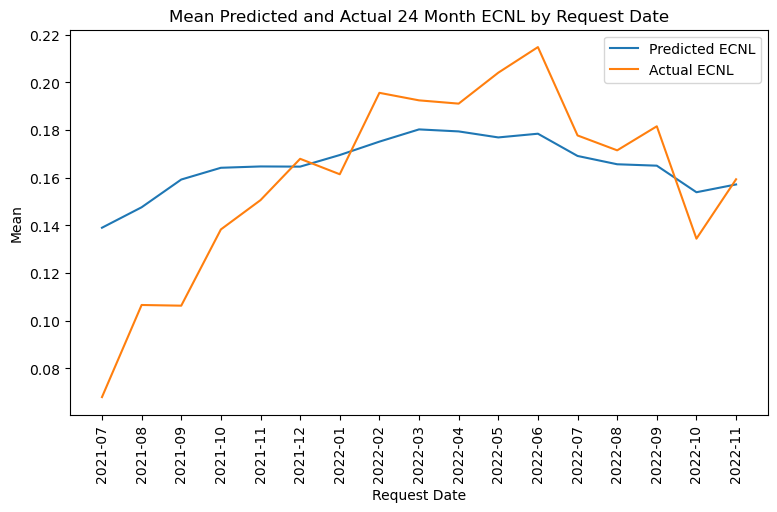

In [42]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean Predicted and Actual 24 Month ECNL by Request Date')
ax.set_xlabel('Request Date')
ax.set_ylabel('Mean')
ax.plot(x, df['ECNL'], label='Predicted ECNL')
ax.plot(x, df['actual_ecnl'], label='Actual ECNL')
ax.set_xticklabels(x, rotation=90)
# legend
ax.legend()

# save
str_filename = 'plt_ecnl.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### PD

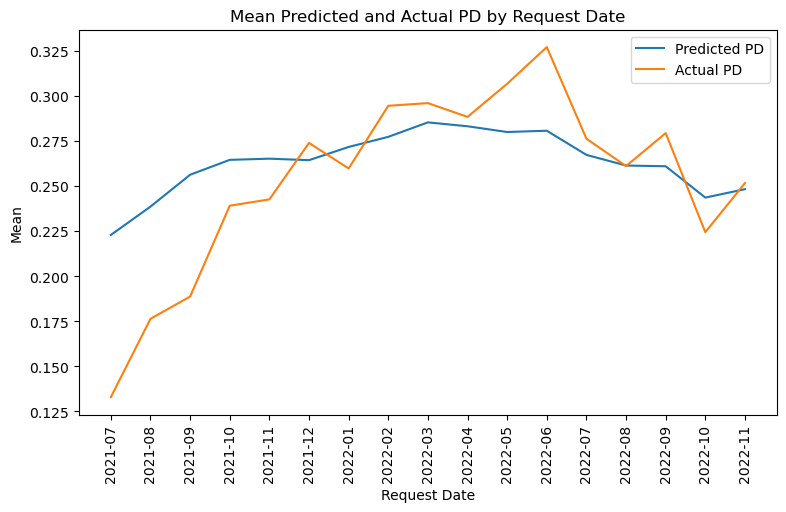

In [43]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean Predicted and Actual PD by Request Date')
ax.set_xlabel('Request Date')
ax.set_ylabel('Mean')
ax.plot(x, df['PD'], label='Predicted PD')
ax.plot(x, df[str_target], label='Actual PD')
ax.set_xticklabels(x, rotation=90)
# legend
ax.legend()

# save
str_filename = 'plt_pd.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### LGD

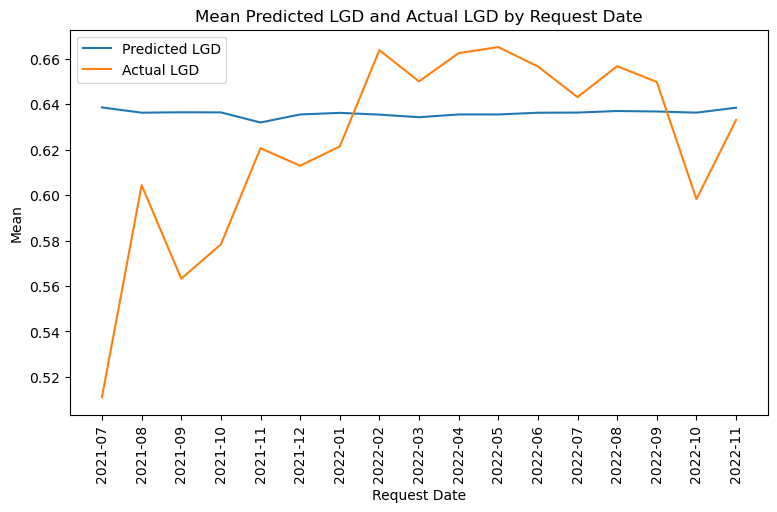

In [44]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean Predicted LGD and Actual LGD by Request Date')
ax.set_xlabel('Request Date')
ax.set_ylabel('Mean')
ax.plot(x, df['LGD_predicted'], label='Predicted LGD')
ax.plot(x, df['actual_lgd'], label='Actual LGD')
ax.set_xticklabels(x, rotation=90)
# legend
ax.legend()

# # add ltv
# ax2 = ax.twinx()
# ax2.set_ylabel('LTV')
# ax2.plot(x, df['ENG-loan_to_value'], color='Red', label='LTV')
# ax2.legend(loc='lower right')

# save
str_filename = 'plt_lgd.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Associations with LTV

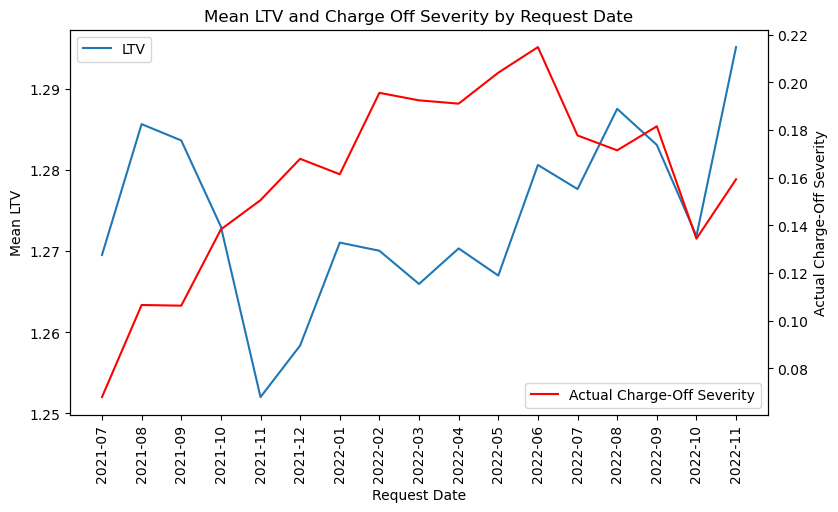

In [45]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean LTV and Charge Off Severity by Request Date')
ax.set_xlabel('Request Date')
ax.set_ylabel('Mean LTV')
ax.plot(x, df['ENG-loan_to_value'], label='LTV')
ax.set_xticklabels(x, rotation=90)
ax.legend(loc='upper left')

# second y
ax2 = ax.twinx()
ax2.set_ylabel('Actual Charge-Off Severity')
ax2.plot(x, df['actual_ecnl'], label='Actual Charge-Off Severity', color='red')
ax2.legend(loc='lower right')

# show
plt.show()

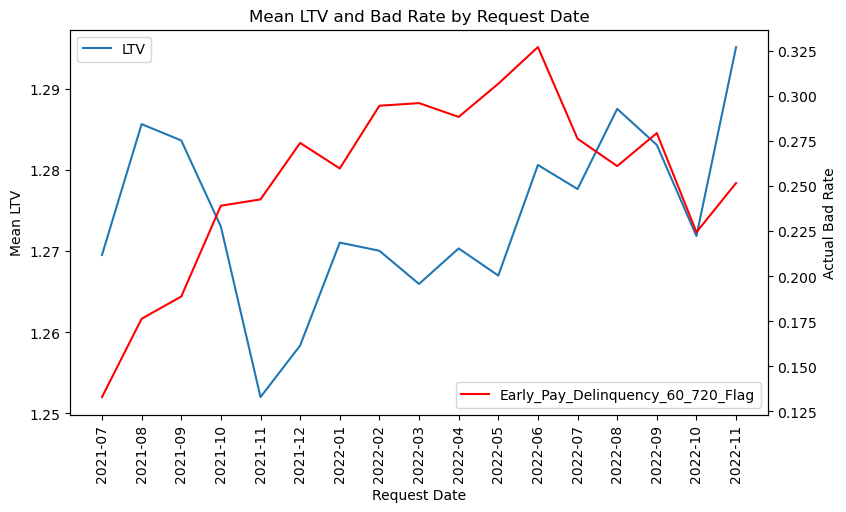

In [46]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Mean LTV and Bad Rate by Request Date')
ax.set_xlabel('Request Date')
ax.set_ylabel('Mean LTV')
ax.plot(x, df['ENG-loan_to_value'], label='LTV')
ax.set_xticklabels(x, rotation=90)
ax.legend(loc='upper left')

# second y
ax2 = ax.twinx()
ax2.set_ylabel('Actual Bad Rate')
ax2.plot(x, df[str_target], label=str_target, color='red')
ax2.legend(loc='lower right')

# show
plt.show()

#### Associations with BK

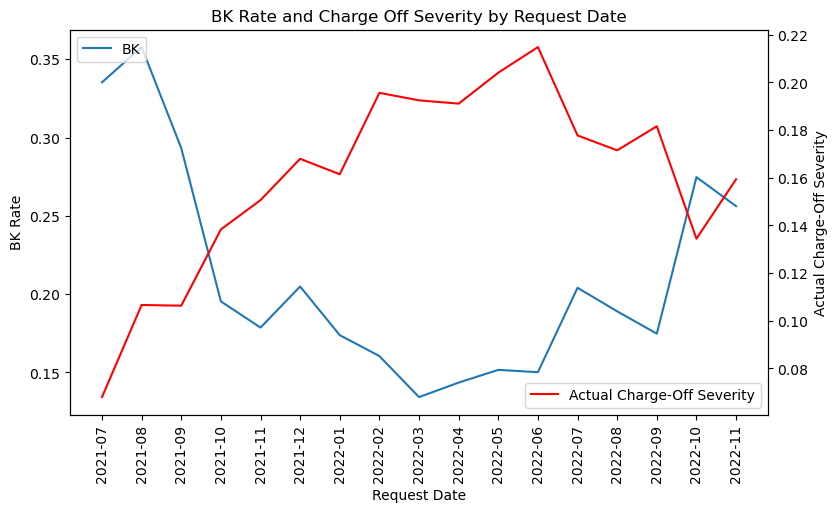

In [47]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('BK Rate and Charge Off Severity by Request Date')
ax.set_xlabel('Request Date')
ax.set_ylabel('BK Rate')
ax.plot(x, df['ENG-bk'], label='BK')
ax.set_xticklabels(x, rotation=90)
ax.legend(loc='upper left')

# second y
ax2 = ax.twinx()
ax2.set_ylabel('Actual Charge-Off Severity')
ax2.plot(x, df['actual_ecnl'], label='Actual Charge-Off Severity', color='red')
ax2.legend(loc='lower right')

# show
plt.show()